# Exploratory Data Analysis (EDA)

This notebook explores ERCOT electricity demand patterns to understand trends, seasonality, and relationships between variables prior to building forecasting models.

## Objectives
- Analyze time-based patterns in electricity demand
- Identify seasonality (monthly and weekly)
- Examine relationships between demand and generation
- Detect anomalies and outliers
- Prepare insights for forecasting models

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Load Processed Data

In [2]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_daily = pd.read_csv(PROCESSED_DIR / "ercot_daily_wide.csv", parse_dates=["period"])

print("Shape:", df_daily.shape)
df_daily.head()

Shape: (2641, 7)


,period,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
0,2019-01-01,950405.0,932790.0,951051.0,24,24,24
1,2019-01-02,1093650.0,1038403.0,1091777.0,24,24,24
2,2019-01-03,1119840.0,1084163.0,1120374.0,24,24,24
3,2019-01-04,1065428.0,1086500.0,1067670.0,24,24,24
4,2019-01-05,931268.0,948521.0,935034.0,24,24,24


## 3. Dataset Overview

In [3]:
# Check on DataFrame's metadata
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2641 entries, 0 to 2640
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   period                 2641 non-null   datetime64[ns]
 1   demand                 2641 non-null   float64       
 2   demand_forecast        2641 non-null   float64       
 3   net_generation         2641 non-null   float64       
 4   demand_count           2641 non-null   int64         
 5   demand_forecast_count  2641 non-null   int64         
 6   net_generation_count   2641 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 144.6 KB


In [4]:
# Descriptive statistics
df_daily.describe()

,period,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
count,2641,2.641000e+03,2.641000e+03,2.641000e+03,2641.0,2641.000000,2641.000000
mean,2022-08-13 14:32:23.809163264,1.170104e+06,1.175355e+06,1.167428e+06,24.0,23.981825,23.990913
min,2019-01-01 00:00:00,7.961360e+05,0.000000e+00,3.619710e+05,24.0,0.000000,7.000000
25%,2020-10-22 00:00:00,1.000026e+06,9.992840e+05,9.988440e+05,24.0,24.000000,24.000000
50%,2022-08-14 00:00:00,1.135840e+06,1.147901e+06,1.135999e+06,24.0,24.000000,24.000000
75%,2024-06-04 00:00:00,1.316033e+06,1.329095e+06,1.312536e+06,24.0,24.000000,24.000000
max,2026-03-26 00:00:00,1.751031e+06,1.835600e+06,1.745339e+06,24.0,24.000000,24.000000
std,NaN,2.141421e+05,2.190698e+05,2.134633e+05,0.0,0.588117,0.357698


## 4. Time Series Plot
- Trend
- Seasonality
- Spikes

Text(0, 0.5, 'Demand (MWh)')

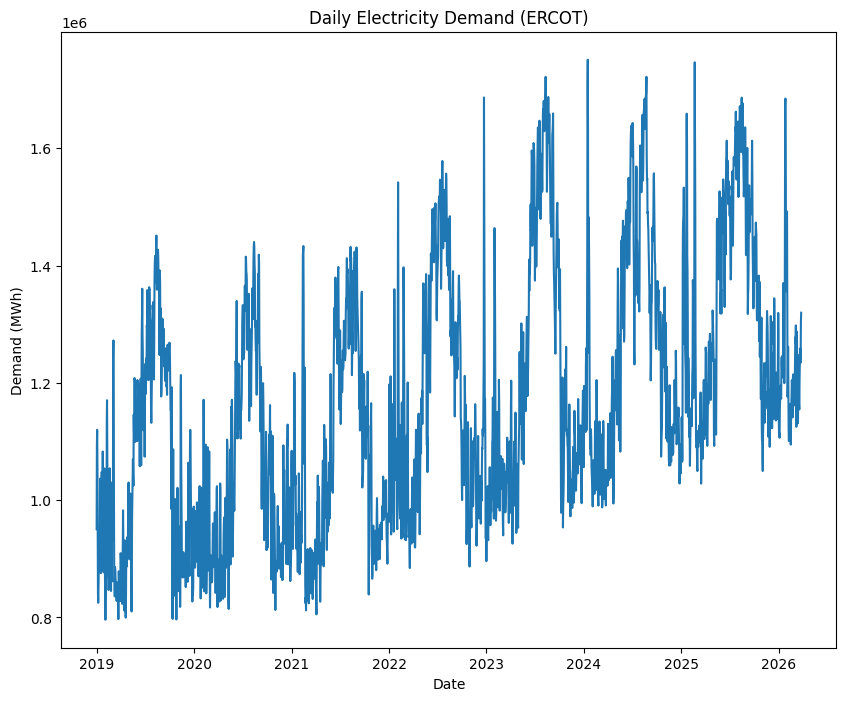

In [5]:
# Time series plot target "demand"
plt.figure(figsize=(10, 8))
plt.plot(df_daily['period'], df_daily["demand"])
plt.title("Daily Electricity Demand (ERCOT)")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")

## 5. Add Time-Based Features

In [6]:
import datetime as dt

df_daily["year"] = df_daily["period"].dt.year
df_daily["month"] = df_daily["period"].dt.month
df_daily["dayofweek"] = df_daily["period"].dt.dayofweek
df_daily["dayofyear"] = df_daily["period"].dt.dayofyear

## 6. Demand Plot by Year
- Growth trend
- Unusual years (e.g., weather events, outages)

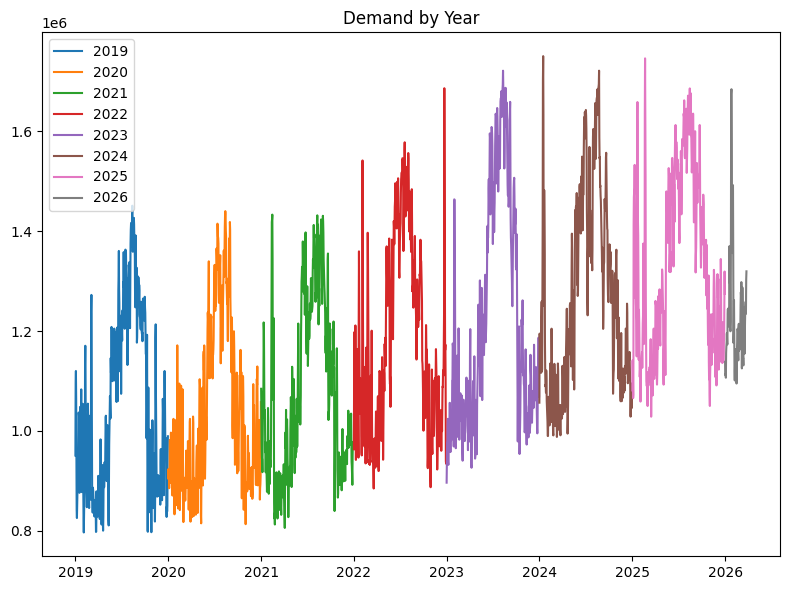

In [7]:
plt.figure(figsize=(8,6))

# Create subset so can plot the dataset by the year
for year in df_daily["year"].unique():
    subset = df_daily[df_daily["year"] == year]
    plt.plot(subset["period"], subset["demand"], label=str(year))

plt.title("Demand by Year")
plt.legend()
plt.tight_layout()

## 7. Monthly Seasonality
- summer peaks (AC usage)
- winter peaks (heating)

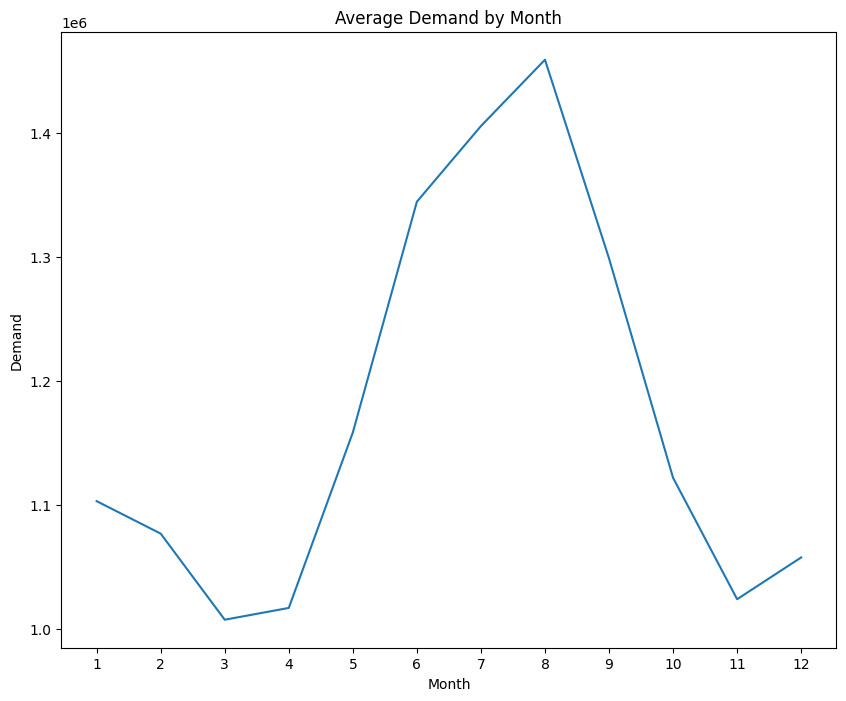

In [8]:
monthly_avg = df_daily.groupby("month")["demand"].mean()

plt.figure(figsize= (10,8))
monthly_avg.plot()

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.xticks(range(1,13))
plt.show()

## 8. Day of Week Pattern
- weekday vs weekend behavior

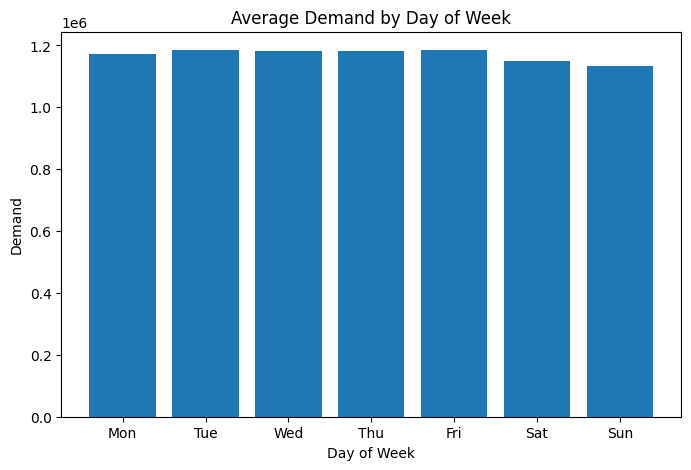

In [9]:
dow_avg = df_daily.groupby("dayofweek")["demand"].mean()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 5))
plt.bar(x= day_names, height=dow_avg)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Demand")
plt.show()

## 9. Rolling Mean (Trend Smoothing via Moving Average)
- Extracting long term trends from noisy data

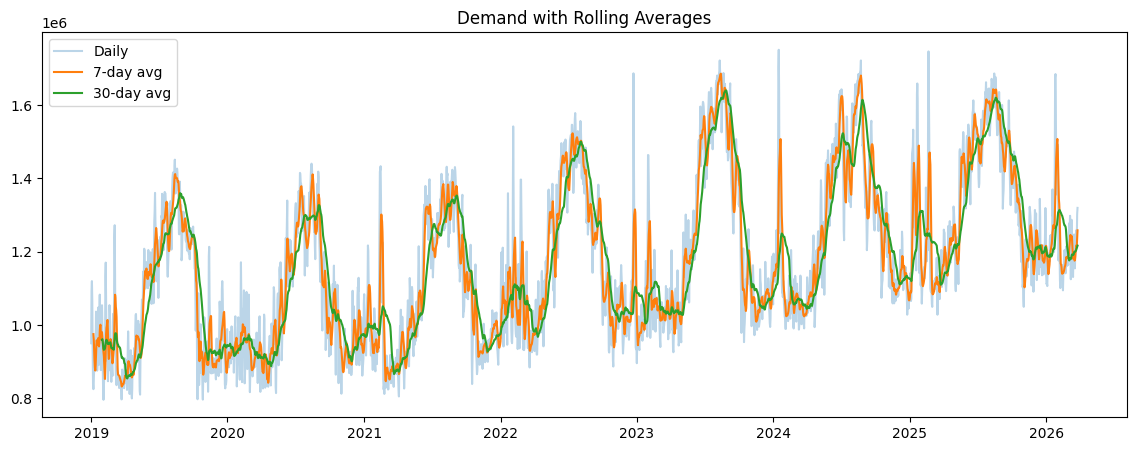

In [10]:
df_daily["rolling_7"] = df_daily["demand"].rolling(7).mean()
df_daily["rolling_30"] = df_daily["demand"].rolling(30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_daily["period"], df_daily["demand"], alpha=0.3, label="Daily")
plt.plot(df_daily["period"], df_daily["rolling_7"], label="7-day avg")
plt.plot(df_daily["period"], df_daily["rolling_30"], label="30-day avg")

plt.title("Demand with Rolling Averages")
plt.legend()
plt.show()

## 10. Demand vs Generation Comparison
- How closely generation follows demand
- Potential lag or imbalance between features

In [11]:
# Column name reminders
df_daily.columns

Index(['period', 'demand', 'demand_forecast', 'net_generation', 'demand_count',
       'demand_forecast_count', 'net_generation_count', 'year', 'month',
       'dayofweek', 'dayofyear', 'rolling_7', 'rolling_30'],
      dtype='object')

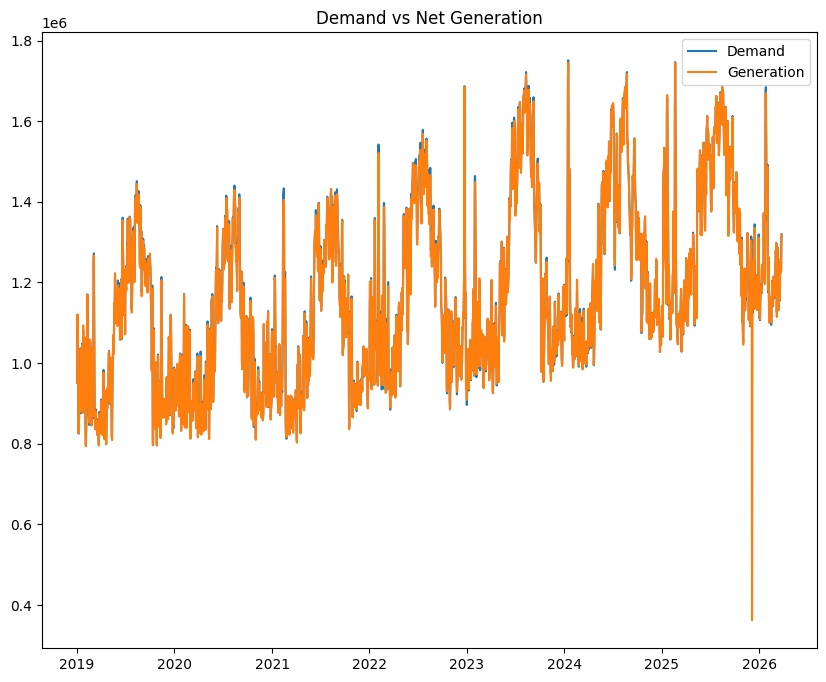

In [12]:
# Comparison plot
plt.figure(figsize=(10, 8))
plt.plot(df_daily["period"], df_daily["demand"], label="Demand")
plt.plot(df_daily["period"], df_daily["net_generation"], label="Generation")

plt.title("Demand vs Net Generation")
plt.legend()
plt.show()

## 11. Correlation Analysis
- Corelation analysis between "demand" & "net_generation"

In [13]:
corr = df_daily[["demand", "net_generation"]].corr()
print(corr)

                  demand  net_generation
demand          1.000000        0.995466
net_generation  0.995466        1.000000


## 12. Scatter Plot
- net_generation vs demand

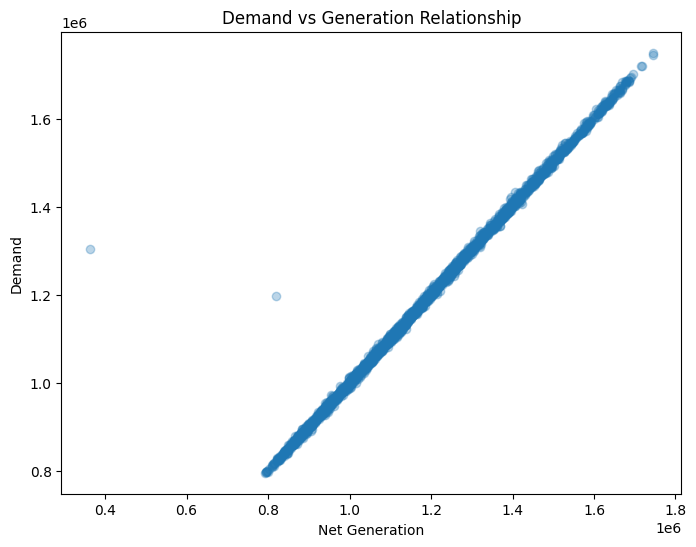

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df_daily["net_generation"], df_daily["demand"], alpha=0.3)
plt.xlabel("Net Generation")
plt.ylabel("Demand")
plt.title("Demand vs Generation Relationship")
plt.show()

## 13. Distribution of Demand
- skewness
- outliers

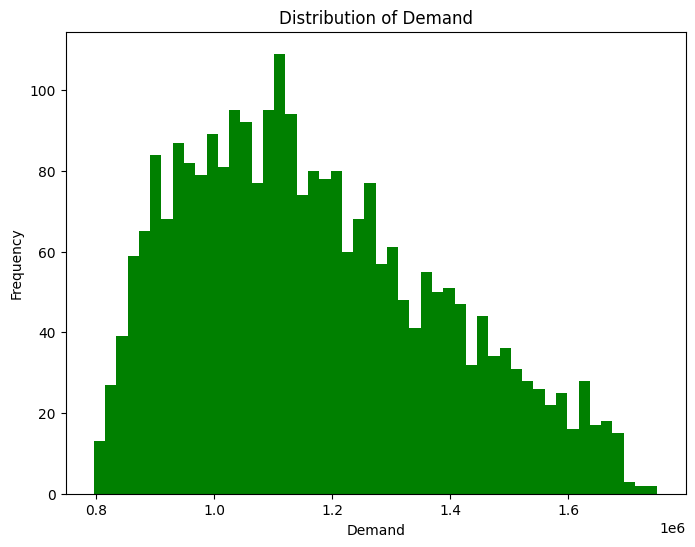

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(df_daily["demand"], bins=50, color="green")
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

## 14. Outlier Detection

In [16]:
# Check in average demand
df_daily["demand"].mean()

np.float64(1170104.0897387352)

In [17]:
# Manualy calculating lower and top outliers
q1 = df_daily["demand"].quantile(0.25)
q3 = df_daily["demand"].quantile(0.75)

inter_qr = q3 - q1

lower = q1 - 1.5 * inter_qr
upper = q3 + 1.5 * inter_qr

outliers = df_daily[(df_daily["demand"] < lower) | (df_daily["demand"] > upper)]

print("Outliers:", len(outliers))
outliers.head()

Outliers: 0


,period,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count,year,month,dayofweek,dayofyear,rolling_7,rolling_30


## 15. Compare Deman with Forecast

/tmp/ipykernel_8608/1336173712.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


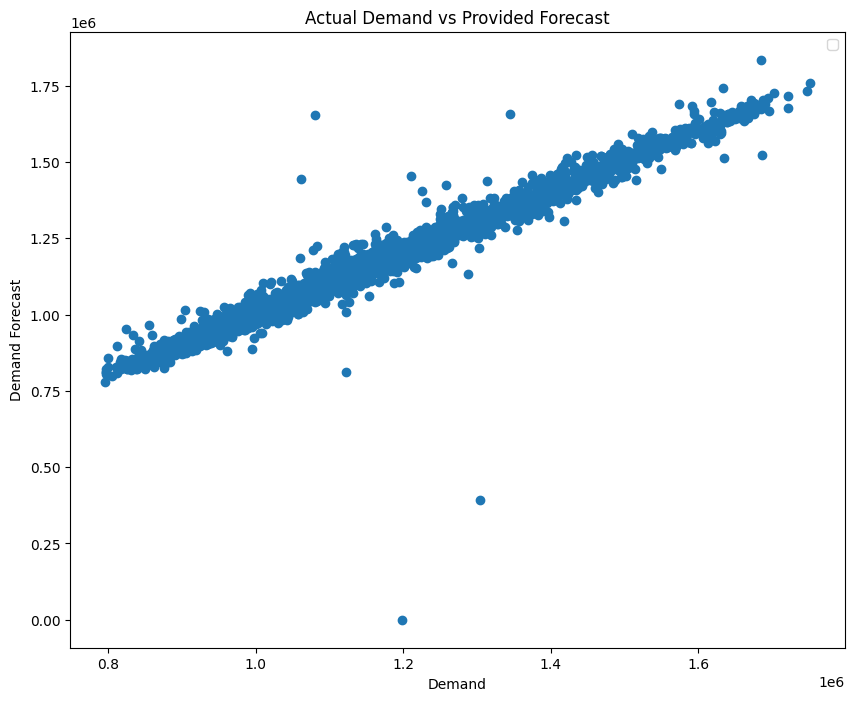

In [18]:
# Compare actual demand and forecast values
plt.figure(figsize= (10,8))
plt.scatter(df_daily["demand"], df_daily["demand_forecast"])
plt.xlabel("Demand")
plt.ylabel("Demand Forecast")
plt.title("Actual Demand vs Provided Forecast")
plt.legend()

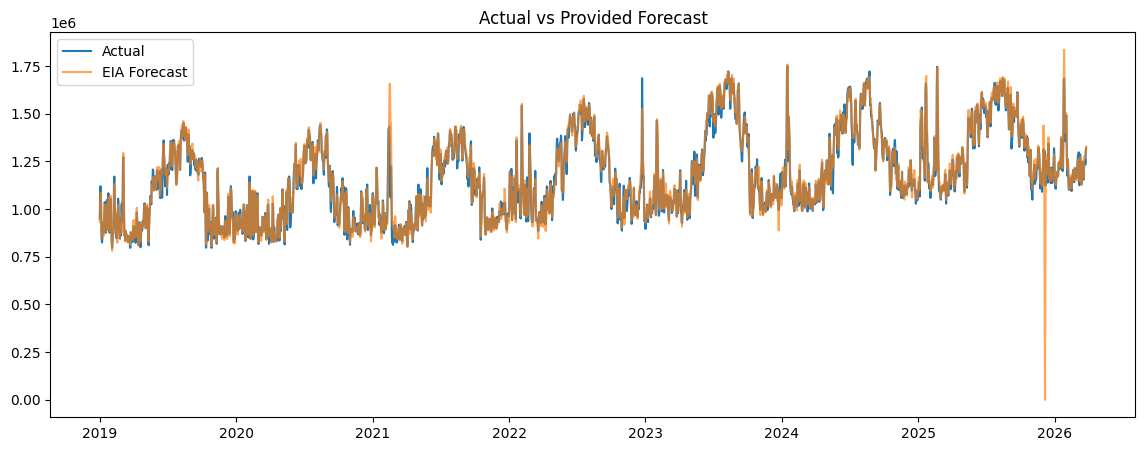

In [19]:
# Compare actual vs forecast demand for the selected time period
plt.figure(figsize=(14, 5))
plt.plot(df_daily["period"], df_daily["demand"], label="Actual")
plt.plot(df_daily["period"], df_daily["demand_forecast"], label="EIA Forecast", alpha=0.7)

plt.title("Actual vs Provided Forecast")
plt.legend()

## 16. Key Findings
- Electricity demand shows strong seasonal behavior, with peaks during summer and winter months, likely driven by cooling and heating usage.

- Demand is generally lower on weekends compared to weekdays, indicating reduced commercial and industrial activity.

- Rolling averages reveal a stable long-term trend, with short-term spikes corresponding to extreme weather conditions.

- Net generation is highly correlated with demand, suggesting that electricity supply closely follows consumption patterns.

- Several outliers are observed in demand, likely associated with unusual weather events such as heatwaves or cold snaps.

- Some auxiliary features (generation and forecast) contain partial data on certain days, highlighting the importance of data quality checks before modeling.

- The provided day-ahead demand forecast (from EIA) will be used as a benchmark in later stages to evaluate the performance of custom forecasting models.